In [1]:
import os
import logging

os.environ.setdefault("KERAS_BACKEND", "torch")

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
import keras
from keras.layers import Dense, Input, Conv2D, MaxPool2D, UpSampling2D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.models import Model


def reconstruction_accuracy(y_true, y_pred):
    return keras.ops.mean(
        keras.ops.cast(keras.ops.abs(y_true - y_pred) < 0.1, "float32")
    )


reconstruction_accuracy.__name__ = "accuracy"


def plot_training_history(history, title):
    h = history.history
    ep = np.arange(1, len(h["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ep, h["loss"], label="train")
    axes[0].plot(ep, h["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    for ak, vak in (
        ("accuracy", "val_accuracy"),
        ("reconstruction_accuracy", "val_reconstruction_accuracy"),
    ):
        if ak in h and vak in h:
            axes[1].plot(ep, h[ak], label="train")
            axes[1].plot(ep, h[vak], label="val")
            axes[1].set_title(f"{title}: accuracy")
            axes[1].set_xlabel("epoch")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            break
    plt.tight_layout()
    plt.show()

In [2]:
train = pd.read_csv("fashion-mnist_train.csv")
train_x = train[list(train.columns)[1:]].values
train_y = train["label"].values
train_x = train_x / 255
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.2)
train_x = train_x.reshape(-1, 784)
val_x = val_x.reshape(-1, 784)

In [3]:
input_layer = Input(shape=(784,))
encode_layer1 = Dense(1500, activation="relu")(input_layer)
encode_layer2 = Dense(1000, activation="relu")(encode_layer1)
encode_layer3 = Dense(500, activation="relu")(encode_layer2)
latent_view_1 = Dense(32, activation="sigmoid")(encode_layer3)
decode_layer1 = Dense(500, activation="relu")(latent_view_1)
decode_layer2 = Dense(1000, activation="relu")(decode_layer1)
decode_layer3 = Dense(1500, activation="relu")(decode_layer2)
output_layer = Dense(784)(decode_layer3)
model = Model(input_layer, output_layer)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     1,177,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │        16,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │        16,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1500)           │     1,501,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │     1,176,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,390,816 (24.38 MB)

 Trainable params: 6,390,816 (24.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.4651 - loss: 0.0622 - val_accuracy: 0.6149 - val_loss: 0.0367 - learning_rate: 5.0000e-04
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.6402 - loss: 0.0305 - val_accuracy: 0.6745 - val_loss: 0.0254 - learning_rate: 5.0000e-04
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.6872 - loss: 0.0237 - val_accuracy: 0.7014 - val_loss: 0.0220 - learning_rate: 5.0000e-04
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.7083 - loss: 0.0207 - val_accuracy: 0.7212 - val_loss: 0.0194 - learning_rate: 5.0000e-04
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.7237 - loss: 0.0188 - val_accuracy: 0.7336 - val_loss: 0.0178 - learning_rate: 5.0000e-04
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.7401 - loss: 0.0171 - val_accuracy: 0.7469 - val_loss: 0.0165 - learning_rate: 5.0000e-04
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - acc

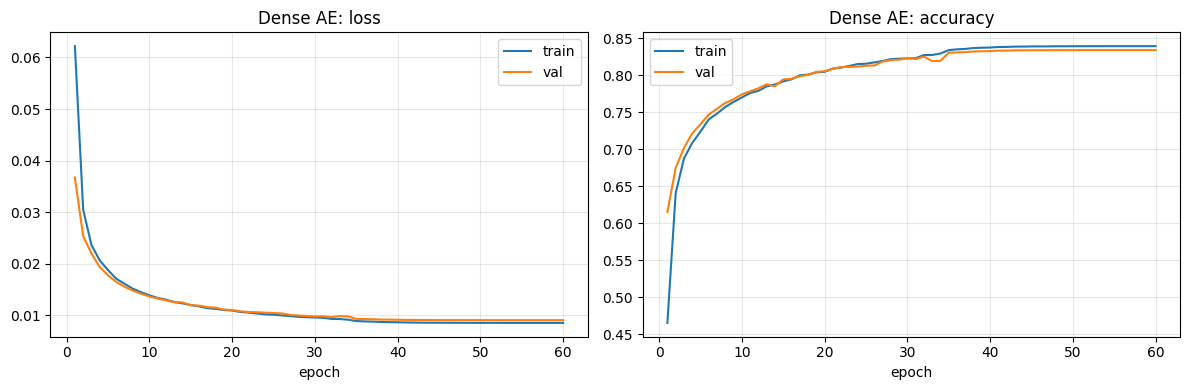

In [9]:
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="mse",
    metrics=[reconstruction_accuracy],
)
early_stopping = EarlyStopping(
    monitor="val_loss", min_delta=0, patience=5, verbose=1, mode="auto"
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)
history_dense = model.fit(
    train_x,
    train_x,
    epochs=60,
    batch_size=512,
    validation_data=(val_x, val_x),
    callbacks=[early_stopping, reduce_lr],
)
plot_training_history(history_dense, "Dense AE")

[dense AE] after predict — val loss=0.009075 accuracy=0.833856


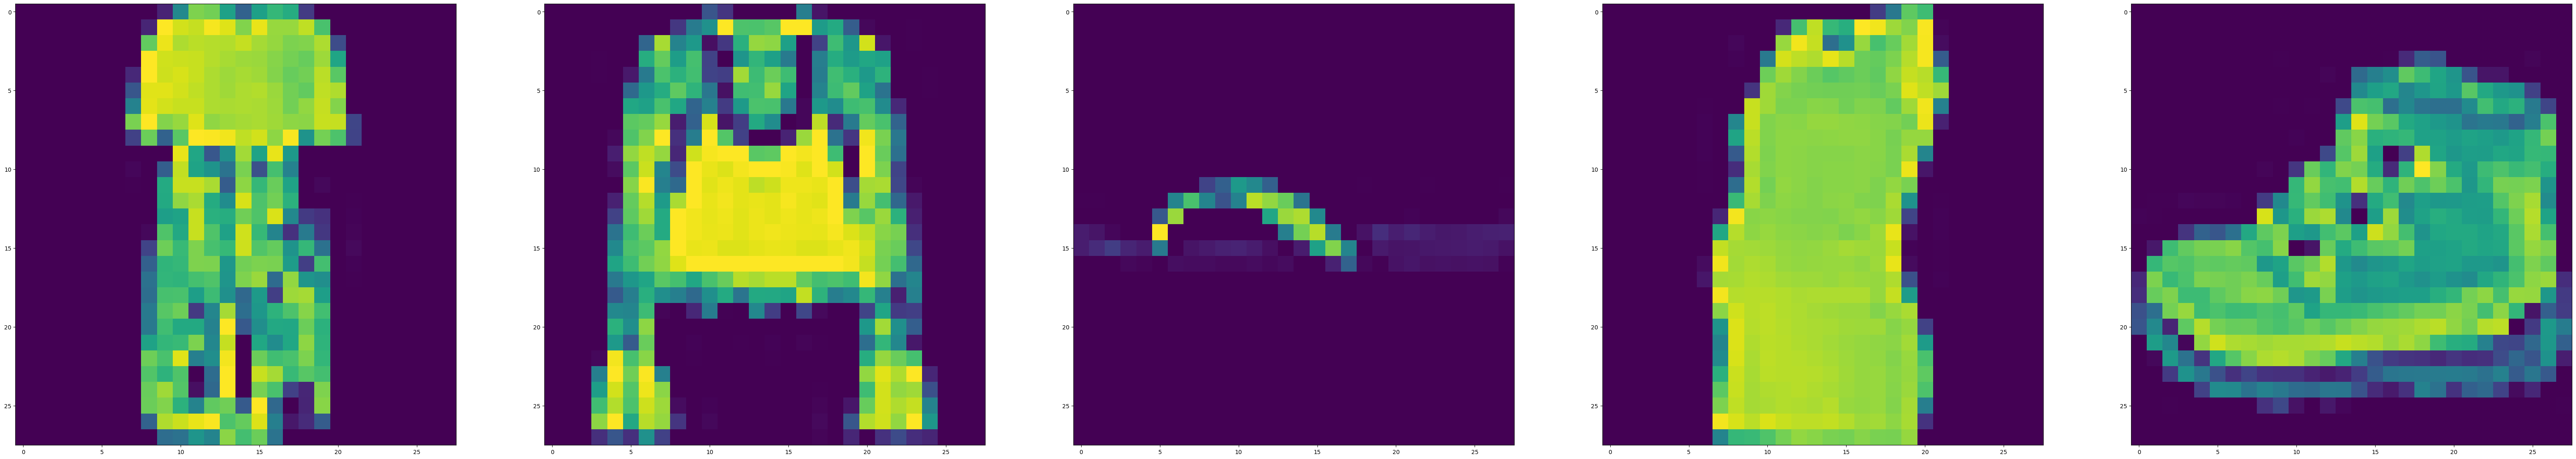

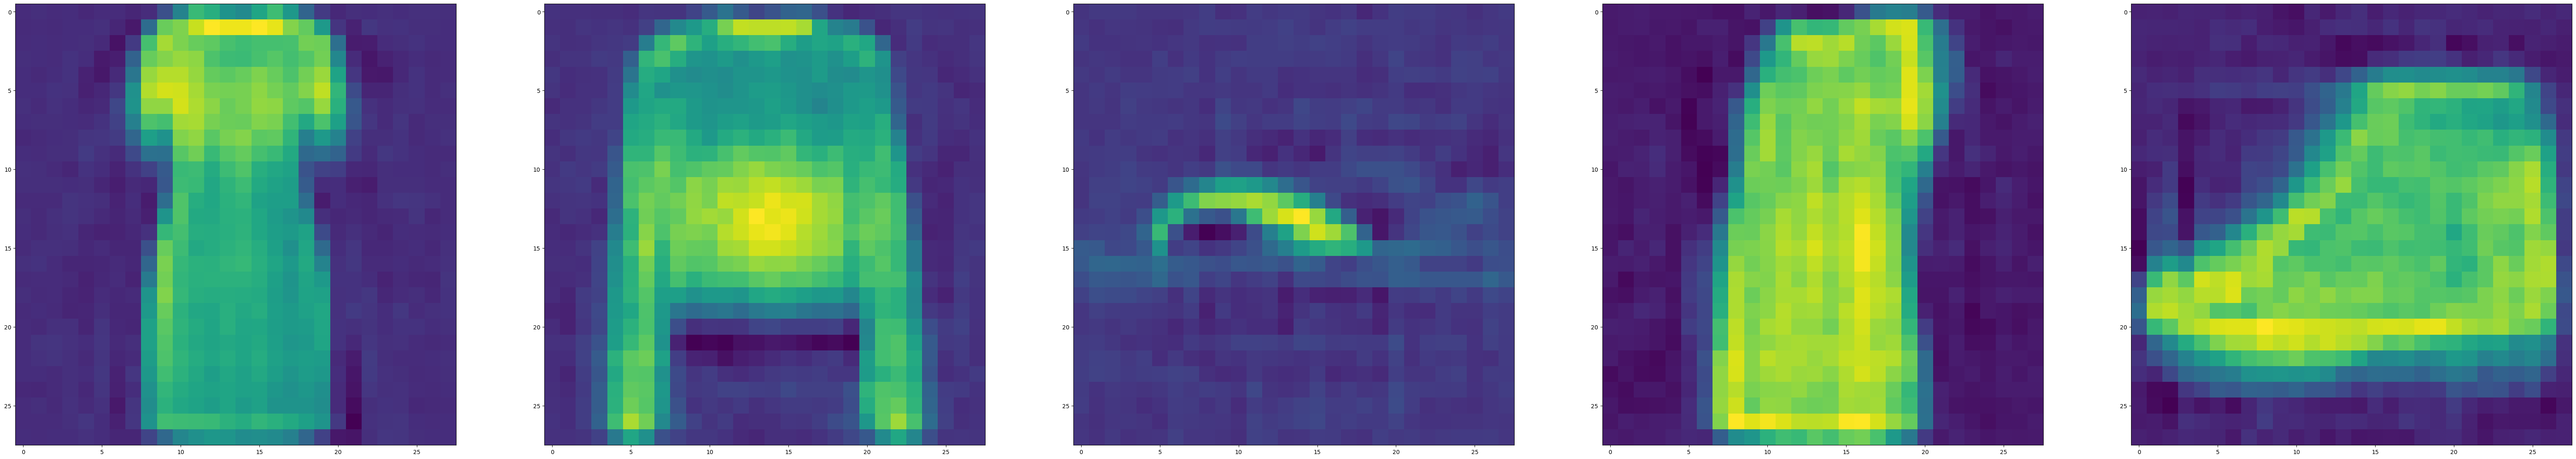

In [10]:
preds = model.predict(val_x, verbose=0)
loss_dense, acc_dense = model.evaluate(val_x, val_x, verbose=0)
logging.info(
    "[dense AE] after predict — val loss=%.6f accuracy=%.6f",
    float(loss_dense),
    float(acc_dense),
)

f, ax = plt.subplots(1, 5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(val_x[i].reshape(28, 28))
plt.show()

f, ax = plt.subplots(1, 5)
f.set_size_inches(80, 40)
for i in range(5):
    ax[i].imshow(preds[i].reshape(28, 28))
plt.show()

In [4]:
train_x = train[list(train.columns)[1:]].values
train_x, val_x = train_test_split(train_x, test_size=0.2)
train_x = train_x / 255
val_x = val_x / 255
train_x = train_x.reshape(-1, 28, 28, 1)
val_x = val_x.reshape(-1, 28, 28, 1)

In [5]:
def salt_pepper(images, amount=0.1):
    out = np.empty_like(images)
    for i, img in enumerate(images):
        noisy = random_noise(img.squeeze(), mode="s&p", amount=amount)
        out[i] = noisy[..., np.newaxis]
    return out


train_x_n = salt_pepper(train_x, amount=0.1)
val_x_n = salt_pepper(val_x, amount=0.1)

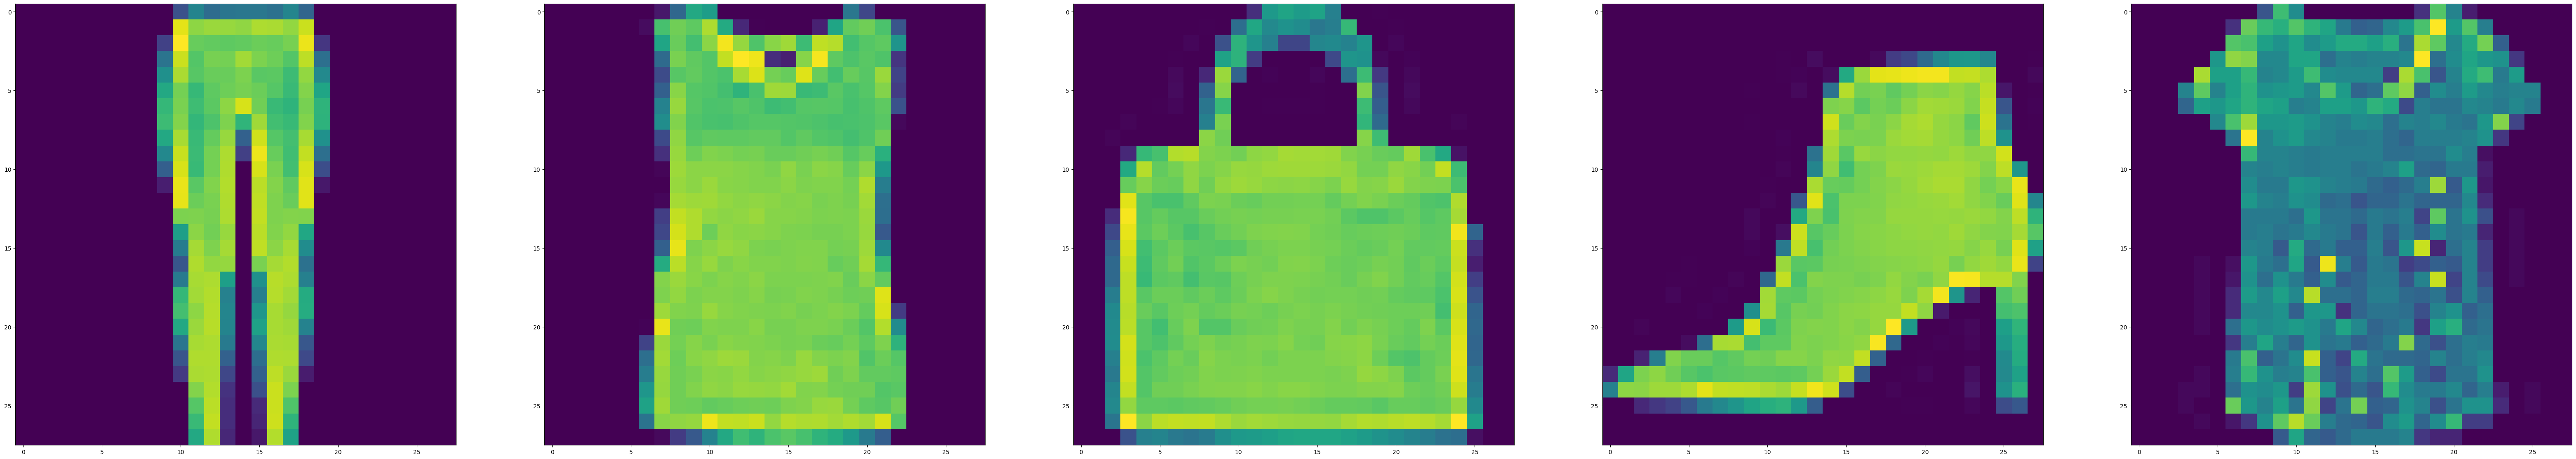

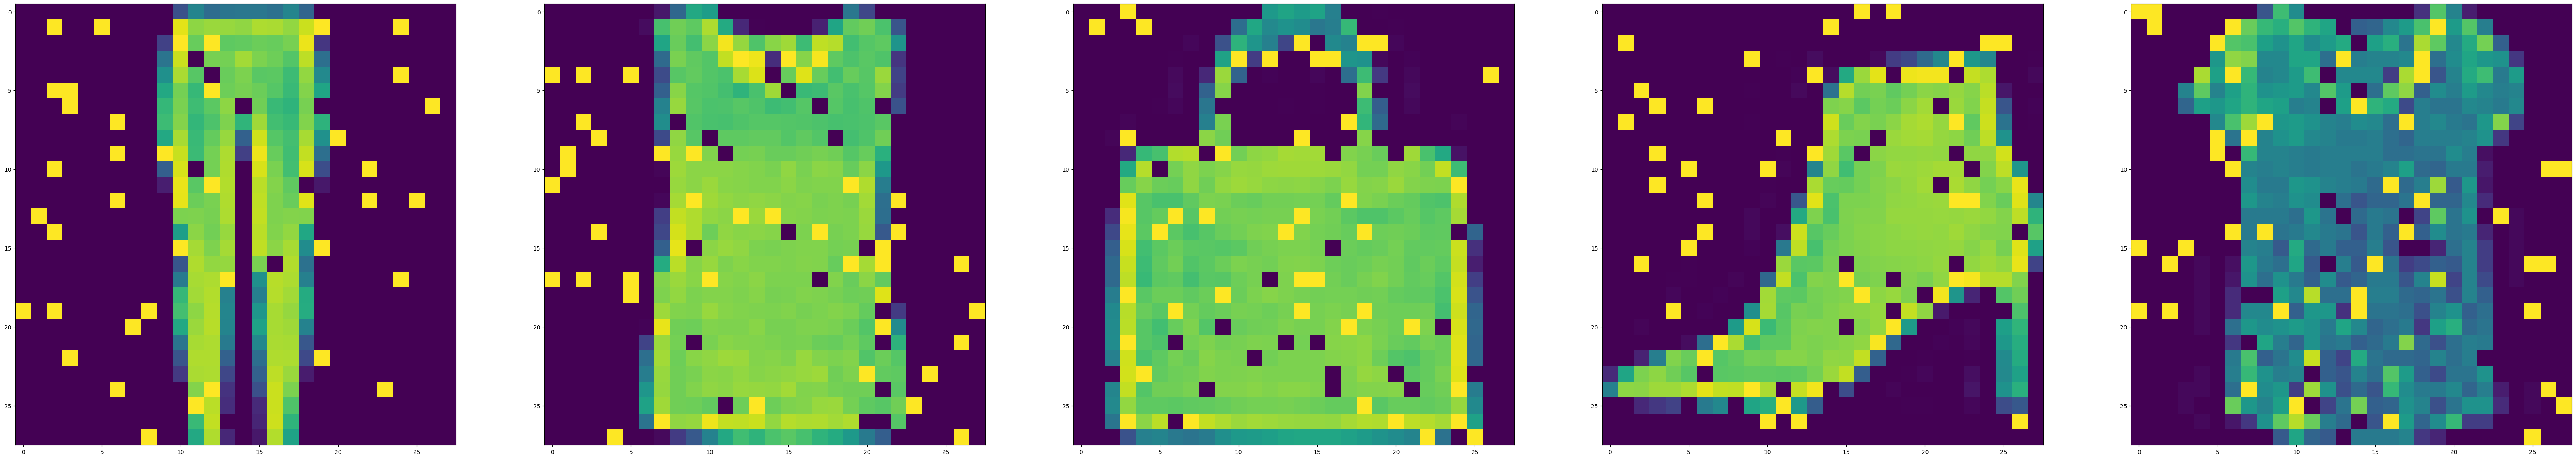

In [6]:
f, ax = plt.subplots(1, 5)
f.set_size_inches(80, 40)
for i in range(5, 10):
    ax[i - 5].imshow(train_x[i].reshape(28, 28))
plt.show()

f, ax = plt.subplots(1, 5)
f.set_size_inches(80, 40)
for i in range(5, 10):
    ax[i - 5].imshow(train_x_n[i].reshape(28, 28))
plt.show()

In [7]:
input_layer = Input(shape=(28, 28, 1))
encoded_layer1 = Conv2D(64, (3, 3), activation="relu", padding="same")(input_layer)
encoded_layer1 = MaxPool2D((2, 2), padding="same")(encoded_layer1)
encoded_layer2 = Conv2D(32, (3, 3), activation="relu", padding="same")(encoded_layer1)
encoded_layer2 = MaxPool2D((2, 2), padding="same")(encoded_layer2)
encoded_layer3 = Conv2D(16, (3, 3), activation="relu", padding="same")(encoded_layer2)
latent_view = MaxPool2D((2, 2), padding="same")(encoded_layer3)
decoded_layer1 = Conv2D(16, (3, 3), activation="relu", padding="same")(latent_view)
decoded_layer1 = UpSampling2D((2, 2))(decoded_layer1)
decoded_layer2 = Conv2D(32, (3, 3), activation="relu", padding="same")(decoded_layer1)
decoded_layer2 = UpSampling2D((2, 2))(decoded_layer2)
decoded_layer3 = Conv2D(64, (3, 3), activation="relu")(decoded_layer2)
decoded_layer3 = UpSampling2D((2, 2))(decoded_layer3)
output_layer = Conv2D(1, (3, 3), padding="same")(decoded_layer3)
model_2 = Model(input_layer, output_layer)
model_2.compile(optimizer="adam", loss="mse", metrics=[reconstruction_accuracy])
model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 326ms/step - accuracy: 0.7689 - loss: 0.0147 - val_accuracy: 0.7714 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 337ms/step - accuracy: 0.7719 - loss: 0.0144 - val_accuracy: 0.7667 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 340ms/step - accuracy: 0.7737 - loss: 0.0142 - val_accuracy: 0.7757 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 343ms/step - accuracy: 0.7762 - loss: 0.0140 - val_accuracy: 0.7777 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 351ms/step - accuracy: 0.7786 - loss: 0.0137 - val_accuracy: 0.7780 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.7798 - loss: 0.0136 - val_accuracy: 0.7832 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 346ms/step - accuracy: 0.7830 - loss: 0.

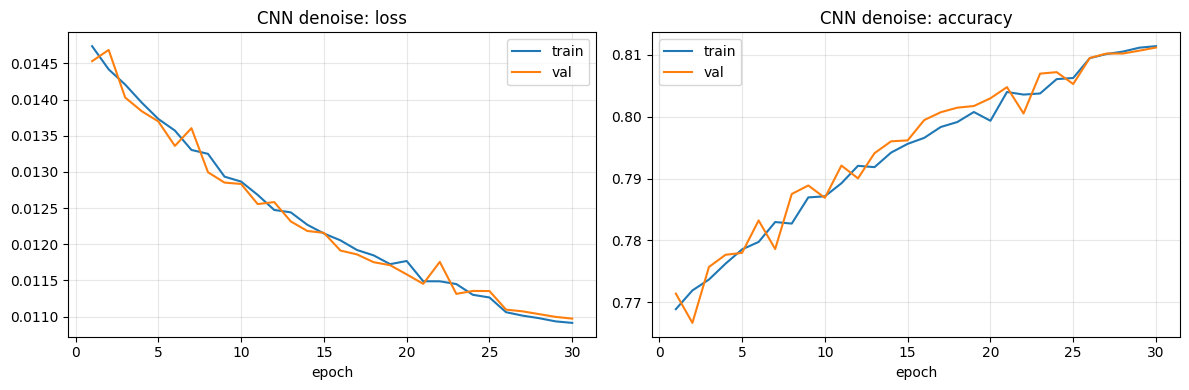

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss", min_delta=0, patience=50, verbose=5, mode="auto"
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)
history = model_2.fit(
    train_x_n,
    train_x,
    epochs=30,
    batch_size=512,
    validation_data=(val_x_n, val_x),
    callbacks=[early_stopping, reduce_lr],
)
plot_training_history(history, "CNN denoise")

[CNN denoise] after predict — val_x_n[:10] loss=0.009049 accuracy=0.822066


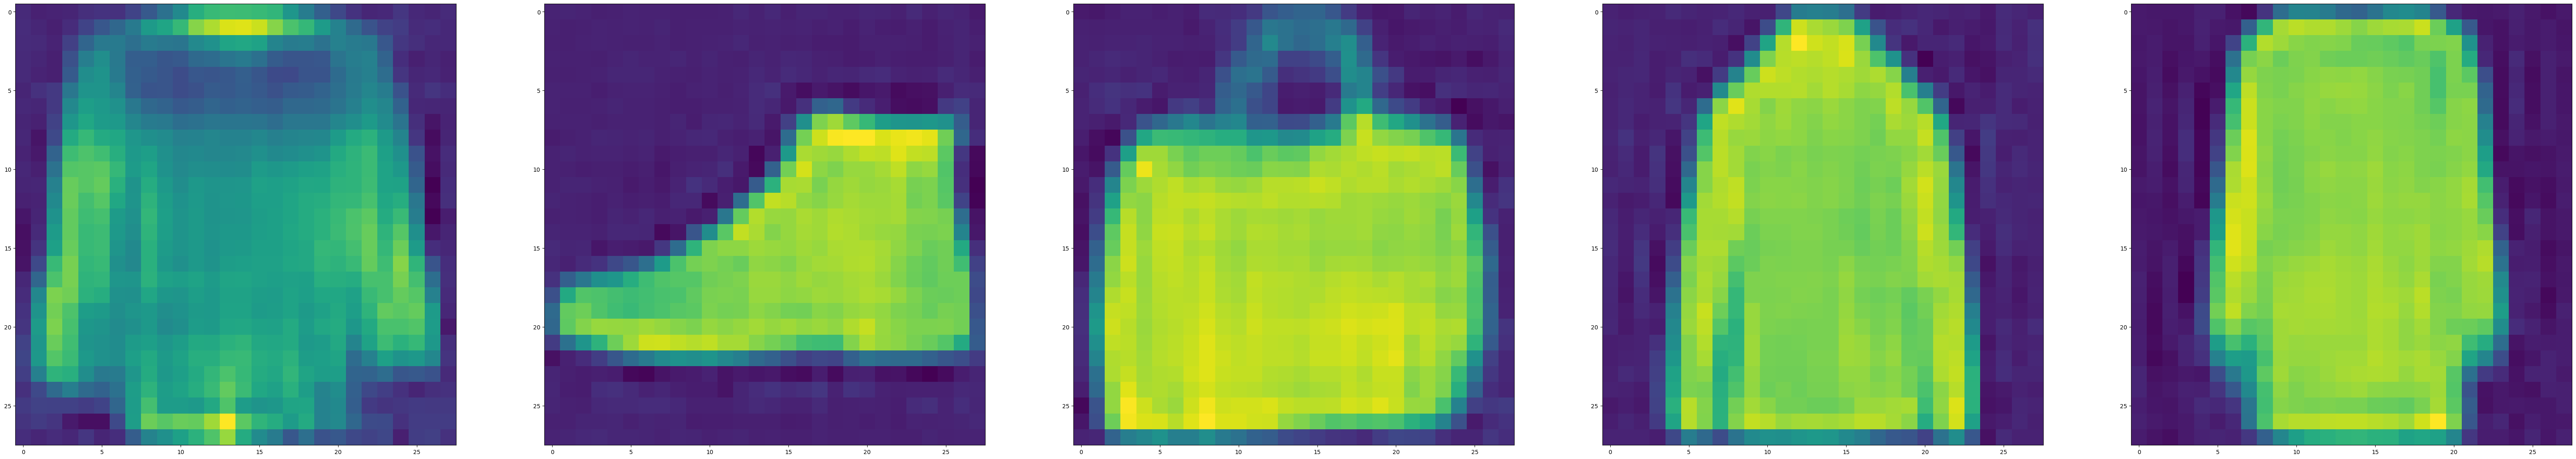

In [11]:
preds = model_2.predict(val_x_n[:10], verbose=0)
loss_cnn, acc_cnn = model_2.evaluate(val_x_n[:10], val_x[:10], verbose=0)
logging.info(
    "[CNN denoise] after predict — val_x_n[:10] loss=%.6f accuracy=%.6f",
    float(loss_cnn),
    float(acc_cnn),
)
f, ax = plt.subplots(1, 5)
f.set_size_inches(80, 40)
for i in range(5, 10):
    ax[i - 5].imshow(preds[i].reshape(28, 28))
plt.show()